<a href="https://colab.research.google.com/github/drm69/PCVK25_3F_12/blob/main/Week5_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#D1  PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

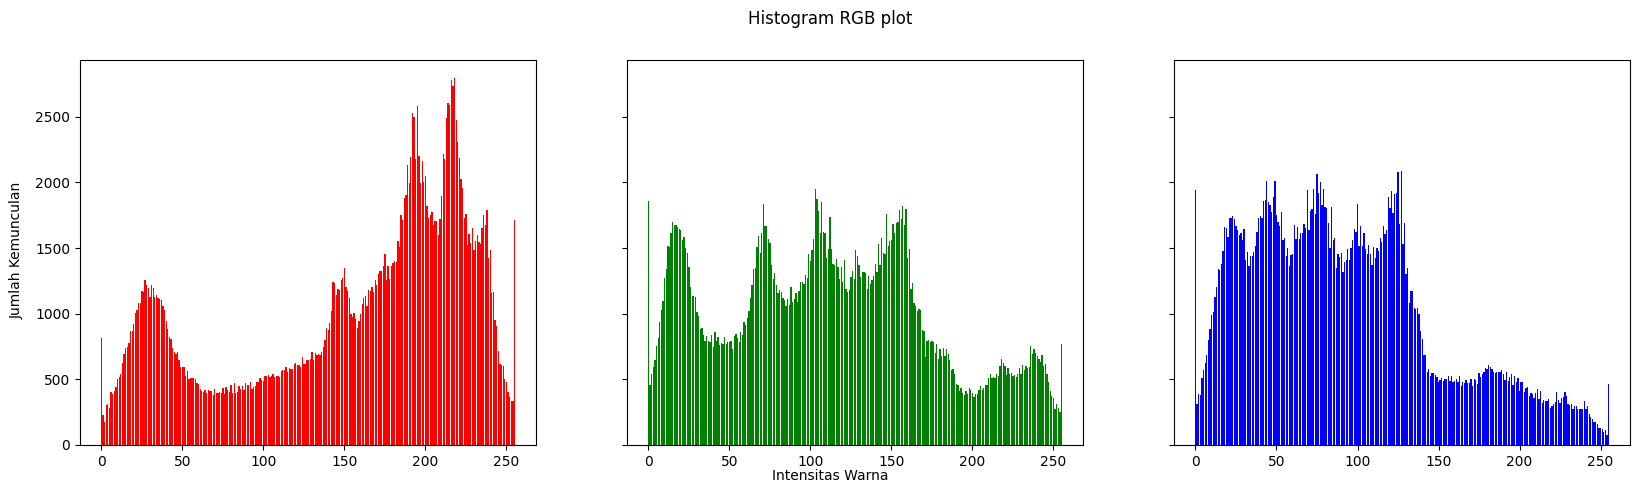

In [3]:
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

#PERTANYAAN PRAKTIKUM D1

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

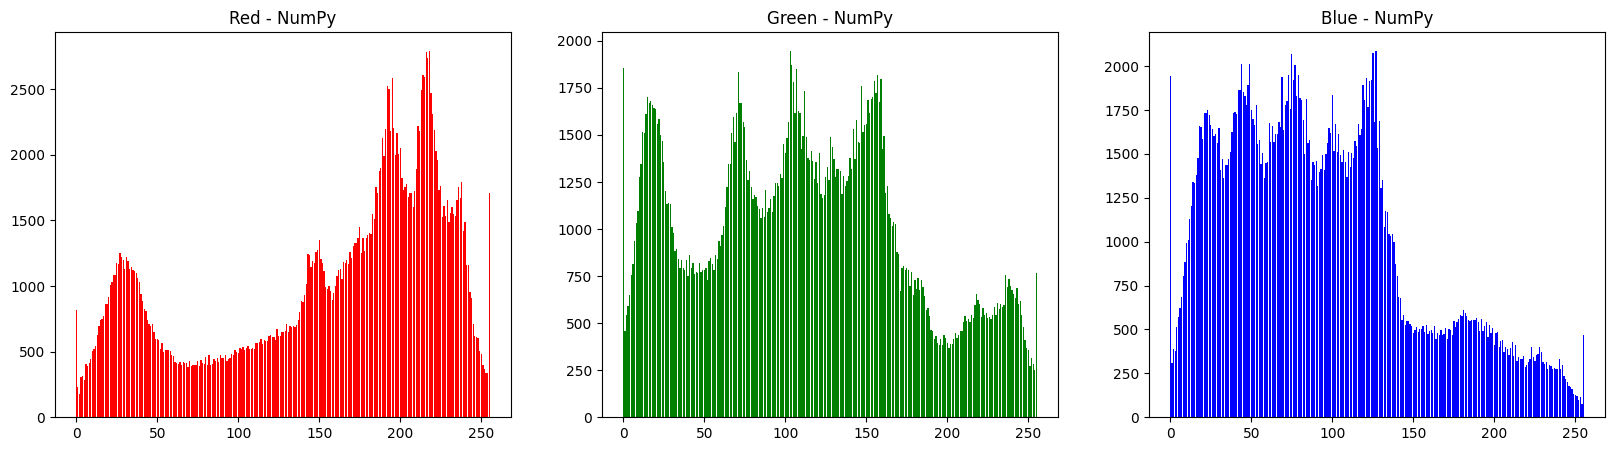

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel
r, g, b = cv.split(img)

# Histogram dengan numpy.histogram
hist_r, bins_r = np.histogram(r.flatten(), bins=256, range=[0,256])
hist_g, bins_g = np.histogram(g.flatten(), bins=256, range=[0,256])
hist_b, bins_b = np.histogram(b.flatten(), bins=256, range=[0,256])

# Plot hasilnya
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
plt.title("Red - NumPy")
plt.bar(bins_r[:-1], hist_r, color='red')

plt.subplot(1,3,2)
plt.title("Green - NumPy")
plt.bar(bins_g[:-1], hist_g, color='green')

plt.subplot(1,3,3)
plt.title("Blue - NumPy")
plt.bar(bins_b[:-1], hist_b, color='blue')

plt.show()

Dari kedua output yang dihasilkan, hasil menggunakan np.histogram memiliki pola yang sama dengan metode manual yang sudah dibuat sebelumnya. Hal ini disebabkan karena keduanya menghitung jumlah piksel dengan nilai intensitas tertentu.

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.

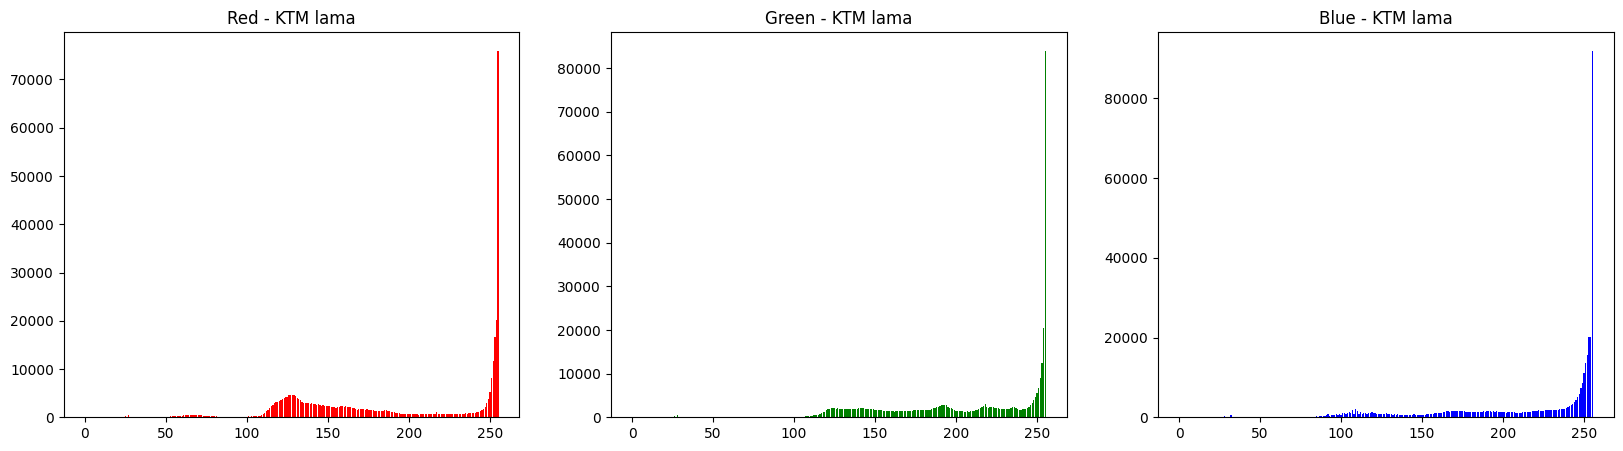

In [5]:
# Baca gambar KTM lama
img2 = cv.imread('/content/drive/MyDrive/images/KTM_lama.jpg')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

# Pisahkan channel
r2, g2, b2 = cv.split(img2)

# Histogram
hist_r2, bins_r2 = np.histogram(r2.flatten(), bins=256, range=[0,256])
hist_g2, bins_g2 = np.histogram(g2.flatten(), bins=256, range=[0,256])
hist_b2, bins_b2 = np.histogram(b2.flatten(), bins=256, range=[0,256])

# Plot histogram KTM lama
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
plt.title("Red - KTM lama")
plt.bar(bins_r2[:-1], hist_r2, color='red')

plt.subplot(1,3,2)
plt.title("Green - KTM lama")
plt.bar(bins_g2[:-1], hist_g2, color='green')

plt.subplot(1,3,3)
plt.title("Blue - KTM lama")
plt.bar(bins_b2[:-1], hist_b2, color='blue')

plt.show()

Dari histogram diatas, dapat disimpulkan bahwa citra KTM lama memiliki distribusi intensitas yang menumpuk di kanan. Hal ini berarti gambar memiliki intensitas warna yang cenderung terang dengan kontras gambar stabil (tidak rendah dan tidak tinggi)

#D-2 PERCOBAAN HISTOGRAM EQUALIZATION

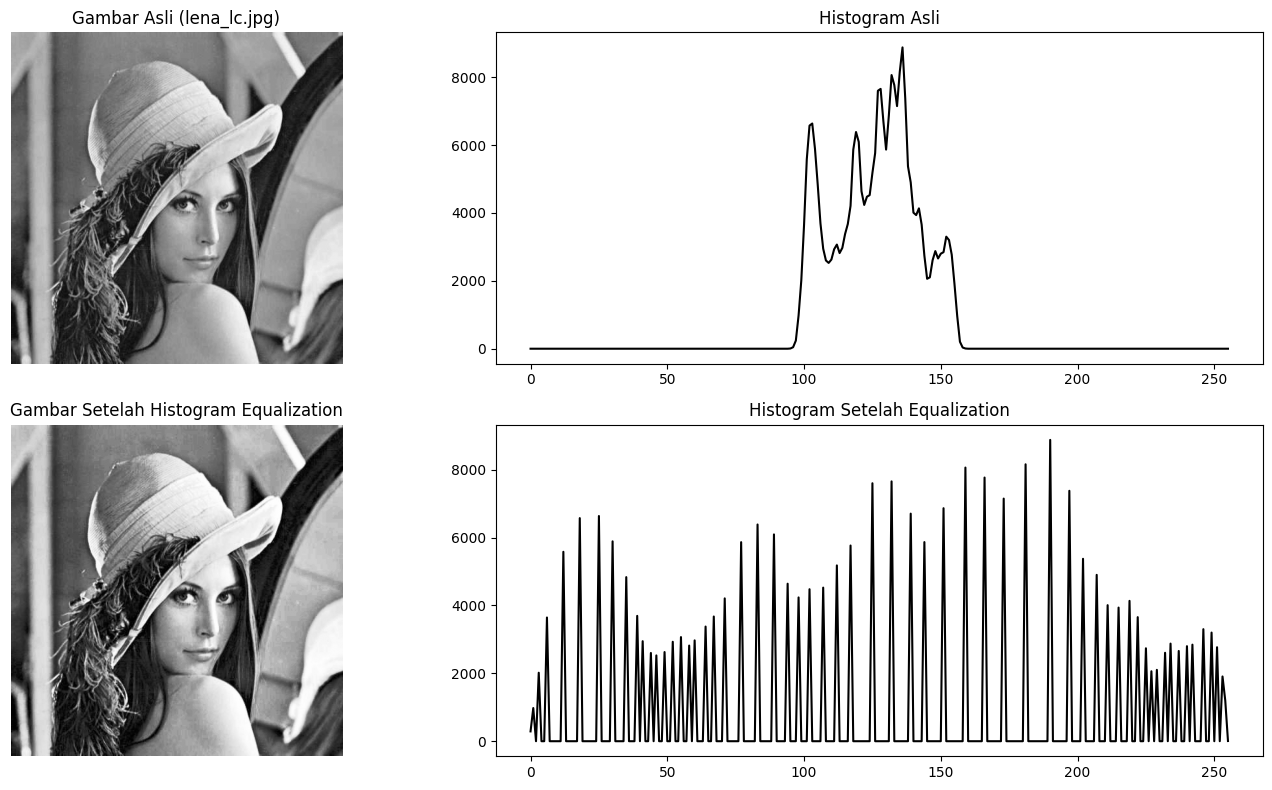

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load gambar dalam grayscale
img = cv.imread('/content/drive/MyDrive/images/lena_lc.jpg', 0)

# Step 1: Hitung histogram (frekuensi)
hist, bins = np.histogram(img.flatten(), 256, [0,256])

# Step 2: Hitung distribusi kumulatif
cdf = hist.cumsum()   # cumulative distribution function
cdf_normalized = cdf * hist.max() / cdf.max()

# Step 3: Normalisasi dengan jumlah pixel
cdf_m = np.ma.masked_equal(cdf,0)
cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
cdf_final = np.ma.filled(cdf_m,0).astype('uint8')

# Step 4: Transformasi ke citra hasil equalization
img_eq = cdf_final[img]

# Step 5: Histogram setelah equalization
hist_eq, bins_eq = np.histogram(img_eq.flatten(), 256, [0,256])

# Plot hasil
plt.figure(figsize=(15,8))

# Gambar asli
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Gambar Asli (lena_lc.jpg)")
plt.axis("off")

# Histogram asli
plt.subplot(2,2,2)
plt.plot(hist, color='black')
plt.title("Histogram Asli")

# Gambar setelah HE
plt.subplot(2,2,3)
plt.imshow(img_eq, cmap='gray')
plt.title("Gambar Setelah Histogram Equalization")
plt.axis("off")

# Histogram setelah HE
plt.subplot(2,2,4)
plt.plot(hist_eq, color='black')
plt.title("Histogram Setelah Equalization")

plt.tight_layout()
plt.show()

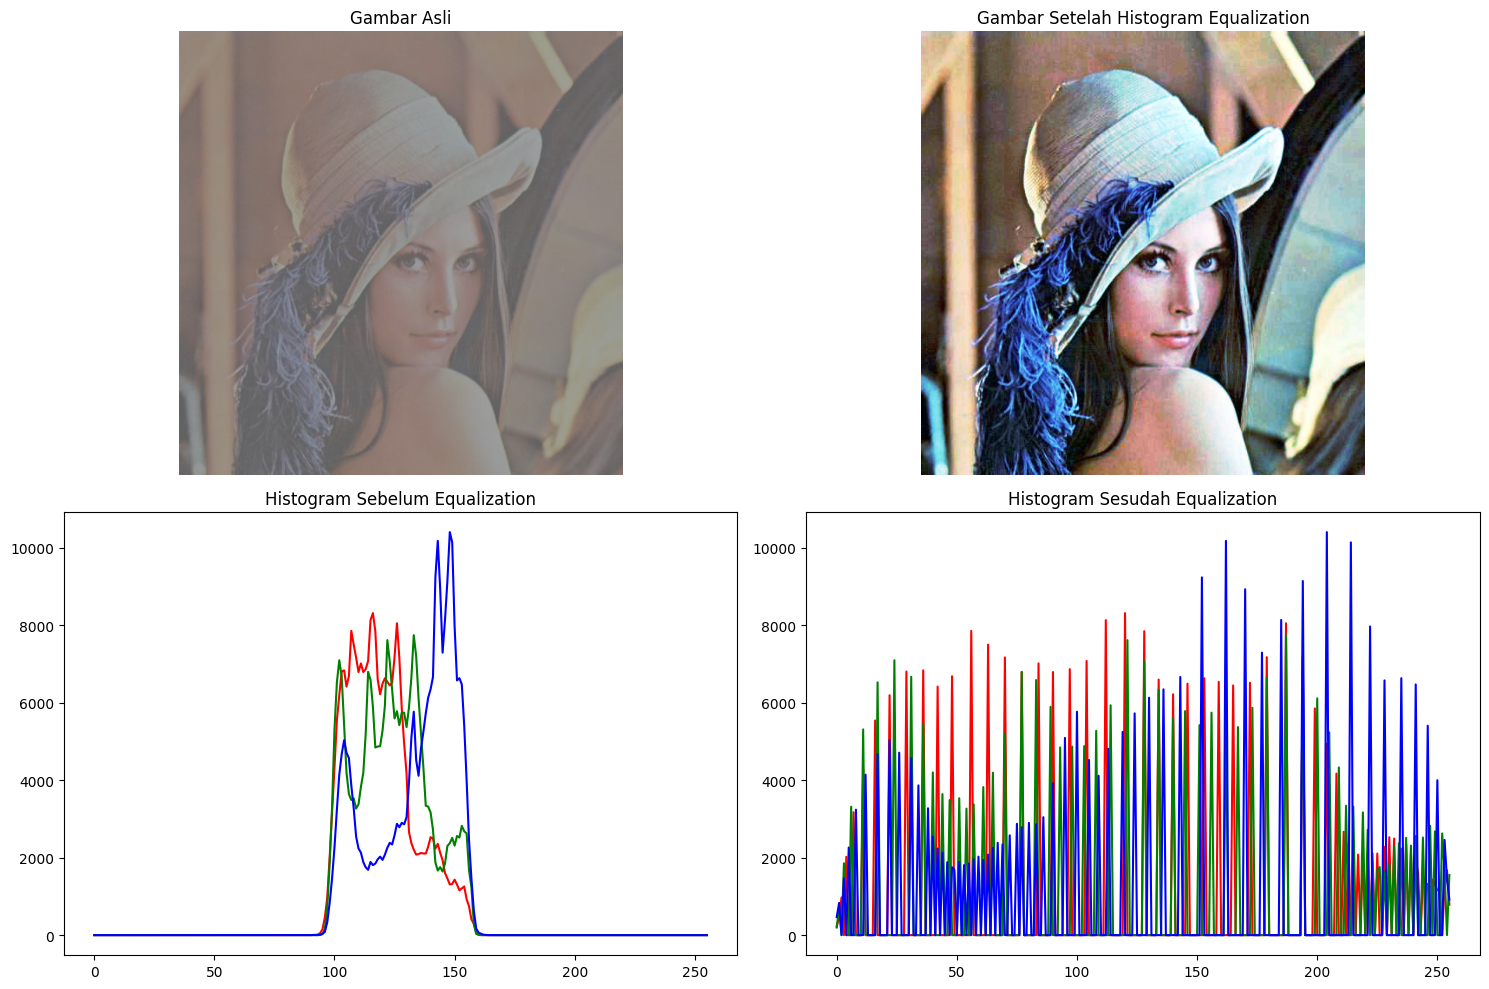

In [7]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Baca gambar berwarna
image = cv.imread('/content/drive/MyDrive/images/lena_lc.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Split channel BGR
b, g, r = cv.split(image)

# Equalize tiap channel
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

# Gabungkan kembali jadi gambar equalized
img_equalized = cv.merge((b_equalized, g_equalized, r_equalized))

# Histogram sebelum equalization
hist_b, _ = np.histogram(b.flatten(), 256, [0,256])
hist_g, _ = np.histogram(g.flatten(), 256, [0,256])
hist_r, _ = np.histogram(r.flatten(), 256, [0,256])

# Histogram setelah equalization
hist_b_eq, _ = np.histogram(b_equalized.flatten(), 256, [0,256])
hist_g_eq, _ = np.histogram(g_equalized.flatten(), 256, [0,256])
hist_r_eq, _ = np.histogram(r_equalized.flatten(), 256, [0,256])

# Plot gambar & histogram
plt.figure(figsize=(15,10))

# Gambar asli
plt.subplot(2,2,1)
plt.imshow(image)
plt.title("Gambar Asli")
plt.axis("off")

# Gambar setelah equalization
plt.subplot(2,2,2)
plt.imshow(img_equalized)
plt.title("Gambar Setelah Histogram Equalization")
plt.axis("off")

# Histogram sebelum
plt.subplot(2,2,3)
plt.plot(hist_r, color='red')
plt.plot(hist_g, color='green')
plt.plot(hist_b, color='blue')
plt.title("Histogram Sebelum Equalization")

# Histogram sesudah
plt.subplot(2,2,4)
plt.plot(hist_r_eq, color='red')
plt.plot(hist_g_eq, color='green')
plt.plot(hist_b_eq, color='blue')
plt.title("Histogram Sesudah Equalization")

plt.tight_layout()
plt.show()

Pada praktikum diatas, hasil dari Equalization yang dilakukan dengan library yang dimiliki oleh CV2 tidak persis sama dengan metode manual flowchart sebelumnya. Meski begitu, konsep yang dilakukan oleh keduanya sama, yaitu meningkatkan kontras citra.